# Ensemble Techniques:  

Ensembles are methods that combines multiple Machine Learning models to create more powerful model.  

### Random Forest:  
Main drawback of Decision tree is that it overfits on the training data.  
Random Forest is the collection of Decision Trees, where each tree is different from another.  


1. In Random Forest, instead of giving whole data to one decision tree we split the data into different parts and provide it to several decision tree.

2. The idea behind random forests is that each tree might do a relatively
good job of predicting, but will likely overfit on part of the data.  

3. If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging their results.  

4. This reduction in overfitting, while retaining the predictive power of the trees, 

In [13]:
#from sklearn.datasets import make_moons
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [14]:
df = pd.read_csv('Breast cancer dataset/Breast_cancer_data.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [16]:
df

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0
...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0
565,20.13,28.25,131.20,1261.0,0.09780,0
566,16.60,28.08,108.30,858.1,0.08455,0
567,20.60,29.33,140.10,1265.0,0.11780,0


In [17]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [19]:
y_test

333    1
273    1
201    0
178    1
85     0
      ..
101    1
329    0
42     0
432    0
41     0
Name: diagnosis, Length: 171, dtype: int64

In [20]:
random_forest = RandomForestClassifier(n_estimators=10, random_state=2, max_depth=5)
random_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=10, random_state=2)

In [22]:
print(f"Accuracy on train data {random_forest.score(X_train, y_train)}")
print(f"Accuracy on test data {random_forest.score(X_test, y_test)}")

Accuracy on train data 0.9698492462311558
Accuracy on test data 0.9181286549707602


In [23]:
y_pred = random_forest.predict(X_test)

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89        68
           1       0.89      0.98      0.94       103

    accuracy                           0.92       171
   macro avg       0.93      0.90      0.91       171
weighted avg       0.92      0.92      0.92       171



In [27]:
conf_mat = confusion_matrix(y_test, y_pred)

conf_mat

array([[ 56,  12],
       [  2, 101]], dtype=int64)

In [28]:
import seaborn as sns


<Axes: >

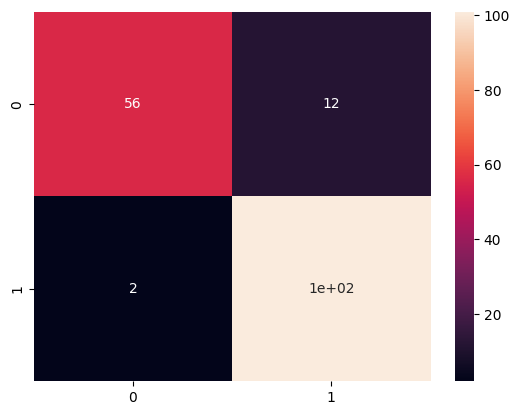

In [29]:
sns.heatmap(conf_mat, annot=True)


In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
columns_ = np.array(X.columns)

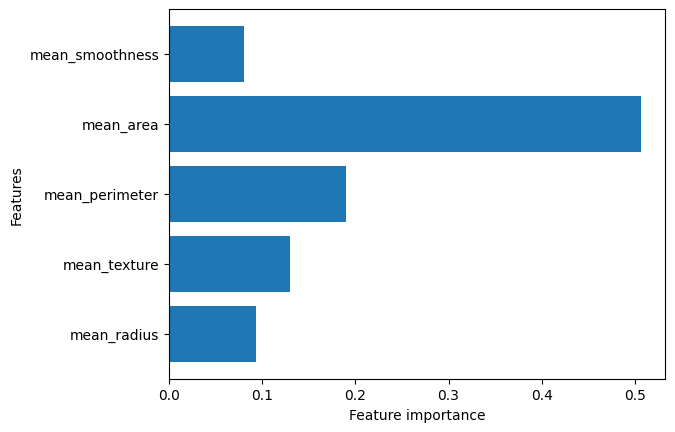

In [33]:
plt.barh(columns_, random_forest.feature_importances_, align='center')
plt.xlabel('Feature importance')
plt.ylabel('Features')

plt.show()

Hyperparameter tuning using gridSearchCV


In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}


In [36]:
rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',   # Important for cancer detection
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [37]:
print("Best Parameters:")
print(grid.best_params_)


Best Parameters:
{'class_weight': None, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [38]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Accuracy: 0.9122807017543859
[[ 55  13]
 [  2 101]]
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        68
           1       0.89      0.98      0.93       103

    accuracy                           0.91       171
   macro avg       0.93      0.89      0.91       171
weighted avg       0.92      0.91      0.91       171



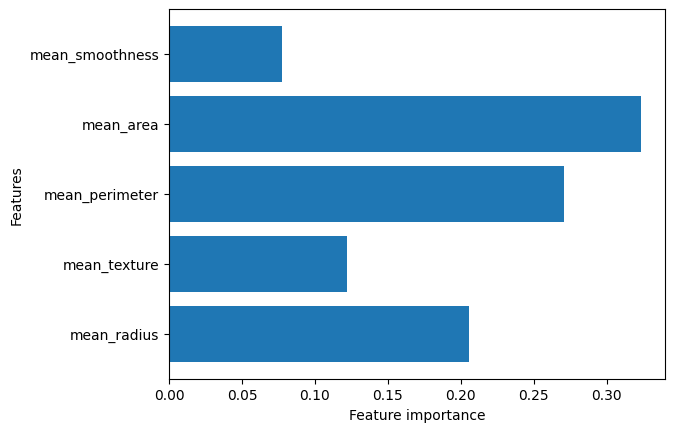

In [39]:
plt.barh(columns_, best_rf.feature_importances_, align='center')
plt.xlabel('Feature importance')
plt.ylabel('Features')

plt.show()